Running inference engine on: cuda
Loading backbone checkpoint structural configuration...
Structural layout found: [(8, 8), (8,), (8, 8), (8,), (1, 8), (1,)] (Total dimensions: 153)
✅ Successfully loaded HyperDiffusion model from epoch 32
Generating 16 hidden neural arrays via reverse diffusion...
🎉 Generation complete! Parameter vector profiles extracted successfully.
Deserializing and querying continuous networks across coordinates...


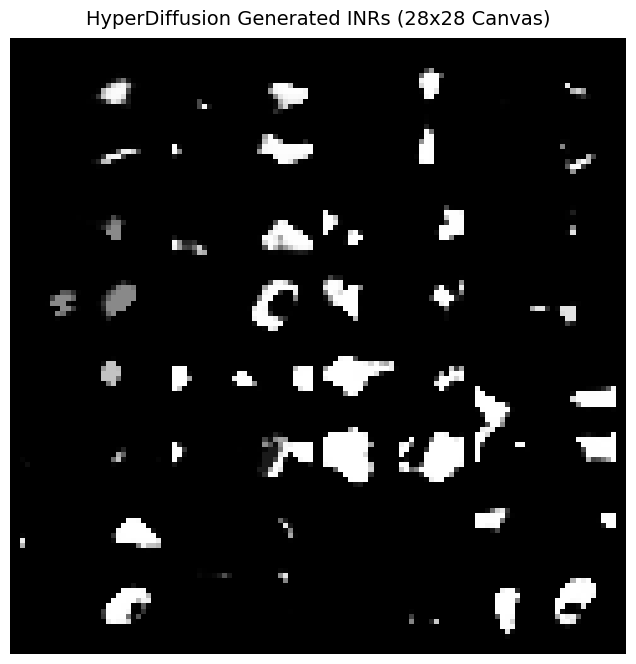

In [17]:
# %% [markdown]
# # 🎨 HyperDiffusion INR Generator Inference Pipeline
# This notebook loads your latest trained HyperDiffusion backbone checkpoint,
# samples continuous parameters via the reverse diffusion process, reconstructs
# them into functional MLP weights, and renders them onto a pixel coordinate grid.

# %%
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Set target acceleration device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running inference engine on: {device}")

# =====================================================================
# 1. ARCHITECTURE & RECONSTRUCTION IMPLEMENTATION
# =====================================================================

class LayerWiseInputProjection(nn.Module):
    def __init__(self, inr_shapes, n_embd):
        super().__init__()
        self.projs = nn.ModuleList([nn.Linear(math.prod(shape), n_embd) for shape in inr_shapes])
    def forward(self, x_list):
        return torch.stack([proj(x) for proj, x in zip(self.projs, x_list)], dim=1)

class LayerWiseOutputProjection(nn.Module):
    def __init__(self, inr_shapes, n_embd):
        super().__init__()
        self.projs = nn.ModuleList([nn.Linear(n_embd, math.prod(shape)) for shape in inr_shapes])
    def forward(self, transformer_outputs):
        return torch.cat([proj(transformer_outputs[:, i, :]) for i, proj in enumerate(self.projs)], dim=1)

class HyperDiffusionTransformer(nn.Module):
    def __init__(self, total_dim, n_embd=256, n_layer=12, n_head=8):
        super().__init__()
        self.total_dim = total_dim
        # Map each individual parameter (token) to embedding space
        self.input_proj = nn.Linear(1, n_embd) 
        # Map back from embedding space to individual parameter values
        self.output_proj = nn.Linear(n_embd, 1)
        
        self.time_mlp = nn.Sequential(
            nn.Linear(n_embd, n_embd * 4), nn.SiLU(), nn.Linear(n_embd * 4, n_embd)
        )
        # Positional embedding for 153 individual tokens
        self.pos_emb = nn.Parameter(torch.randn(1, total_dim, n_embd))
        
        layer = nn.TransformerEncoderLayer(
            d_model=n_embd, nhead=n_head, dim_feedforward=n_embd * 4,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layer)
        
    def get_timestep_embedding(self, t, dim):
        half = dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    
    def forward(self, x_flat, t):
        # x_flat shape: [batch, 153]
        # Reshape to [batch, 153, 1]
        h = self.input_proj(x_flat.unsqueeze(-1)) # [batch, 153, n_embd]
        
        # CALL THE HELPER FUNCTION HERE
        t_emb = self.time_mlp(self.get_timestep_embedding(t, h.shape[-1])).unsqueeze(1)
        
        # Add positional embedding and time embedding
        # Ensure pos_emb matches shape: [1, 153, n_embd]
        h = self.transformer(h + self.pos_emb + t_emb)
        
        # Project back to [batch, 153, 1] then flatten
        return self.output_proj(h).squeeze(-1)

class PositionalEncoding(nn.Module):
    def __init__(self, L=10):
        super().__init__()
        self.L = L

    def forward(self, x):
        out = []
        for i in range(self.L):
            freq = 2.0 ** i
            out.append(torch.sin(freq * np.pi * x))
            out.append(torch.cos(freq * np.pi * x))
        return torch.cat(out, dim=-1)
    
class TargetMNISTINR(nn.Module):
    def __init__(self, layer_shapes, L=2):
        super().__init__()
        self.pos_encoder = PositionalEncoding(L=L)
        
        # Calculate structure dynamically from the layout list
        # We assume your layout provides pairs of (weight_shape, bias_shape)
        # Your layout: [(8, 8), (8,), (8, 8), (8,), (1, 8), (1,)]
        
        layers = []
        # We iterate by 2 because each layer has 1 Weight and 1 Bias
        for i in range(0, len(layer_shapes), 2):
            w_shape = layer_shapes[i]
            # w_shape[1] is input dim, w_shape[0] is output dim
            linear = nn.Linear(w_shape[1], w_shape[0])
            layers.append(linear)
            
            # Add activation based on if it's the last layer
            if i < len(layer_shapes) - 2:
                layers.append(nn.ReLU())
            else:
                layers.append(nn.Sigmoid())
        
        self.seq = nn.Sequential(*layers)
    
    def forward(self, coords):
        return self.seq(self.pos_encoder(coords))


def deserialize_weights_to_inr(flat_vector, layer_shapes):
    model = TargetMNISTINR(layer_shapes)
    state_dict = {}
    curr = 0
    
    # We only want to target the indices where nn.Linear layers exist
    # In your TargetMNISTINR(seq), Linear layers are at 0, 2, 4
    linear_indices = [0, 2, 4] 
    
    for idx, i in enumerate(range(0, len(layer_shapes), 2)):
        w_shape = layer_shapes[i]
        b_shape = layer_shapes[i+1]
        
        w_size = math.prod(w_shape)
        b_size = math.prod(b_shape)
        
        w_tensor = flat_vector[curr : curr + w_size].view(w_shape)
        curr += w_size
        b_tensor = flat_vector[curr : curr + b_size].view(b_shape)
        curr += b_size
        
        # Use the 'seq' naming convention
        seq_idx = linear_indices[idx]
        state_dict[f"seq.{seq_idx}.weight"] = w_tensor
        state_dict[f"seq.{seq_idx}.bias"] = b_tensor
        
    model.load_state_dict(state_dict)
    return model

# %% [markdown]
# ### 2. Load Saved Model State & Schedule Components

# %%
BACKBONE_PATH = "checkpoints/latest_backbone.pt"

if not os.path.exists(BACKBONE_PATH):
    raise FileNotFoundError(f"Could not find model checkpoint file at {BACKBONE_PATH}")

print("Loading backbone checkpoint structural configuration...")
checkpoint = torch.load(BACKBONE_PATH, map_location=device)

# Load layout details stored inside the tracking dictionary
mnist_layout = checkpoint['inr_shapes']
total_dim = sum(math.prod(s) for s in mnist_layout)
print(f"Structural layout found: {mnist_layout} (Total dimensions: {total_dim})")

# Initialize and map weights
model = HyperDiffusionTransformer(total_dim=153, n_embd=200, n_layer=6, n_head=4).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Successfully loaded HyperDiffusion model from epoch {checkpoint['epoch']}")

# Recreate Diffusion Scheduling Coefficients matching training configurations
num_steps = 1000
betas = torch.linspace(1e-4, 0.02, num_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_one_minus_alphas = torch.sqrt(1.0 - alphas_cumprod)
posterior_variance = betas * (1.0 - torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]]) ) / (1.0 - alphas_cumprod)

# %% [markdown]
# ### 3. Run Reverse Diffusion Process (Sampling)

# %%
# Hyperparameters for generation
NUM_SAMPLES = 16  # Total number of continuous parameter spaces to generate

print(f"Generating {NUM_SAMPLES} hidden neural arrays via reverse diffusion...")
with torch.no_grad():
    # Start from pure standard Gaussian noise
    generated_samples = torch.randn(NUM_SAMPLES, total_dim, device=device)
    
    # Trace step-by-step from T=999 back to T=0
    for step in reversed(range(0, num_steps)):
        t_vec = torch.full((generated_samples.shape[0],), step, device=device, dtype=torch.long)
        predicted_noise = model(generated_samples, t_vec)
        
        alpha_t = alphas[step]
        alpha_cumprod_t = alphas_cumprod[step]
        sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas[step]
        
        # Deduct noise step representation estimate
        mean = (1.0 / torch.sqrt(alpha_t)) * (generated_samples - ((betas[step] / sqrt_one_minus_alpha_cumprod_t) * predicted_noise))
        
        if step > 0:
            noise_z = torch.randn_like(generated_samples)
            generated_samples = mean + torch.sqrt(posterior_variance[step]) * noise_z
        else:
            generated_samples = mean

print("🎉 Generation complete! Parameter vector profiles extracted successfully.")

# %% [markdown]
# ### 4. Deserialize Array Vectors & Render Image Canvas

# %%
IMAGE_RESOLUTION = 28 # Coordinate query grid size (28x28 for MNIST)

pixel_batch = []

# Build explicit 2D pixel input layout coordinate map normalized between [-1, 1]
coords = torch.stack(torch.meshgrid(
    torch.linspace(-1, 1, IMAGE_RESOLUTION), 
    torch.linspace(-1, 1, IMAGE_RESOLUTION), 
    indexing="ij"
), dim=-1).view(-1, 2).to(device)

print("Deserializing and querying continuous networks across coordinates...")
for idx, flat_inr in enumerate(generated_samples):
    # Rebuild functional state layout
    active_inr = deserialize_weights_to_inr(flat_inr, mnist_layout).to(device).eval()
    
    # Query spatial coordinates through the newly synthesized network weights
    with torch.no_grad():
        pixels = active_inr(coords).view(1, IMAGE_RESOLUTION, IMAGE_RESOLUTION)
    
    pixel_batch.append(pixels.cpu())

# Stack images into tensor array batch [B, 1, 28, 28]
img_tensors = torch.stack(pixel_batch)

# %% [markdown]
# ### 5. Visualize Generated Results

# %%
# Compose images into a scannable structural visual layout board grid
grid = make_grid(img_tensors, nrow=4, normalize=True, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.title(f"HyperDiffusion Generated INRs ({IMAGE_RESOLUTION}x{IMAGE_RESOLUTION} Canvas)", fontsize=14, pad=10)
plt.show()